# Signature Verification — Siamese CNN

In notebook 1 the plain CNN didn't actually learn *similarity* — it just stacked the
two images and mapped them to a label, which (as 01b showed) let it cheat on a data
leak instead of comparing anything.

This notebook does it properly with a Siamese network. The idea: one small CNN tower,
with shared weights, turns each signature into a 128-d embedding vector. Two signatures
from the same hand should land close together in that space; a forgery should land far
away. So verification becomes "measure the distance between the two embeddings and
compare it to a threshold."

I train this with **contrastive loss**, which directly pulls genuine pairs together and
pushes non-matching pairs apart. Two nice side effects over notebook 1: it generalizes to
people it never trained on, and I can enroll a brand new person from a single reference
signature without retraining.

Techniques used: shared-weight towers (Keras functional API), Conv2D + BatchNorm +
Dropout, a Lambda distance layer, contrastive loss, and an EER-based threshold.

## 1. Imports

In [ ]:
import os
import json
import random
from collections import defaultdict

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import tensorflow as tf
from keras.models import Sequential, Model
from keras.layers import Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout, BatchNormalization, Lambda
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import roc_auc_score, roc_curve

## 2. Load the Dataset

Same ICDAR dataset as notebook 1 — it ships inside the repo, so on Colab I just clone
the repo and point at the `sign_data` folder.

In [ ]:
# clone the project repo (run once) — the dataset ships inside it
!git clone https://github.com/goyashek/Signature-forgery-verification.git

DATA_ROOT = 'Signature-forgery-verification/sign_data'
IMG_DIR   = os.path.join(DATA_ROOT, 'train')

IMG_H, IMG_W = 150, 220

Cloning into 'Signature-forgery-verification'...
remote: Enumerating objects: 2144, done.
remote: Counting objects: 100% (336/336), done.
remote: Compressing objects: 100% (329/329), done.
remote: Total 2144 (delta 18), reused 324 (delta 7), pack-reused 1808 (from 1)
Receiving objects: 100% (2144/2144), 230.40 MiB | 16.00 MiB/s, done.
Resolving deltas: 100% (27/27), done.


## 3. Writer-Independent Split and Leak-Free Pairs

Notebook 1 and 01b turned up two separate data problems that I have to design around
here, otherwise the numbers are meaningless:

1. **The duplicate test folder.** The shipped `test/` folder is just a copy of part of
   `train/`, so I split by *writer id* instead and only test on people the model never
   saw: train ≤ 40, val 41–48, test ≥ 49.

2. **The pairing leak (from 01b).** The shipped CSV only has two kinds of pairs —
   genuine-vs-genuine (match) and genuine-vs-forgery (non-match). That makes the label a
   dead giveaway of which folder the questioned image came from, so a model can "cheat"
   by only looking at that one image. To break it I build the pairs myself from the raw
   folders and add a third recipe: *genuine vs a different writer's genuine*, which is a
   non-match where the questioned image is still genuine. Now a genuine image can be
   either label, so the model is forced to actually compare the two signatures.

So I don't read the CSV at all here — I index the per-writer folders directly.

In [ ]:
# Index the raw folders.
#   genuine[w] = list of writer w's genuine files
#   forg[w]    = list of writer w's forgeries
genuine = defaultdict(list)
forg    = defaultdict(list)

for d in sorted(os.listdir(IMG_DIR)):
    full = os.path.join(IMG_DIR, d)
    if not os.path.isdir(full):
        continue
    files = [os.path.join(d, f) for f in os.listdir(full) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if d.endswith('_forg'):
        forg[int(d.replace('_forg', ''))].extend(files)
    else:
        genuine[int(d)].extend(files)

writers = sorted(set(genuine) & set(forg))
train_writers = [w for w in writers if w <= 40]
val_writers   = [w for w in writers if 41 <= w <= 48]
test_writers  = [w for w in writers if w >= 49]

print('total writers:', len(writers))
print('split ->', len(train_writers), 'train |', len(val_writers), 'val |', len(test_writers), 'test')

total writers: 64
split -> 35 train | 8 val | 21 test


## 4. Building the Pairs

Label semantics for the Siamese setup: **0 = same writer (a match), 1 = non-match**. A
non-match is now one of two things — a forgery of the writer, or a different writer's
genuine signature.

`make_pairs` builds a balanced set per writer using the three recipes. I keep one match,
half a batch of forgery-negatives and half a batch of different-writer-negatives, so the
0/1 classes come out balanced.

In [ ]:
def make_pairs(wset, per_writer, seed=42):
    rng = random.Random(seed)
    wlist = sorted(wset)
    rows = []

    for w in wlist:
        g = genuine.get(w, [])
        if len(g) < 2:
            continue

        # recipe 1 — match: two different genuine signatures of the same writer
        for _ in range(per_writer):
            a, b = rng.sample(g, 2)
            rows.append((a, b, 0))

        # recipe 2 — hard negative: a genuine vs a forgery of the same writer
        for _ in range(per_writer // 2):
            if forg.get(w):
                rows.append((rng.choice(g), rng.choice(forg[w]), 1))

        # recipe 3 — random negative: a genuine vs a *different* writer's genuine
        #            (this is the one that kills the 01b leak)
        for _ in range(per_writer // 2):
            other = rng.choice([x for x in wlist if x != w])
            rows.append((rng.choice(g), rng.choice(genuine[other]), 1))

    rng.shuffle(rows)
    return pd.DataFrame(rows, columns=['img1', 'img2', 'label'])

In [ ]:
train_pairs = make_pairs(train_writers, per_writer=100)
val_pairs   = make_pairs(val_writers,   per_writer=100, seed=1)
test_pairs  = make_pairs(test_writers,  per_writer=100, seed=2)

print('pairs ->', len(train_pairs), 'train |', len(val_pairs), 'val |', len(test_pairs), 'test')
train_pairs.head()

pairs -> 7000 train | 1600 val | 4200 test
             img1            img2  label
0  018/10_018.png  018/08_018.png      0
1  036/10_036.png  012/012_20.PNG      1
2  032/06_032.png  032/11_032.png      0
3  002/002_12.PNG  002/002_10.PNG      0
4  028/11_028.png  028/09_028.png      0


Before training anything, a quick sanity check on the pairs I just built. 01b's whole
point was that a genuine questioned image used to imply "match" — so I want to confirm
that's no longer true. I'll break the training non-matches (label 1) down into forgery
negatives vs different-writer negatives, and check that label 1 now contains plenty of
*genuine* questioned images too.

In [ ]:
train_pairs['img2_is_forg'] = train_pairs['img2'].str.contains('_forg')

print('class balance:', dict(train_pairs['label'].value_counts()))
print()
print('within the non-matches (label 1):')
neg = train_pairs[train_pairs.label == 1]
print('  forgery negatives          :', int((neg.img2_is_forg).sum()))
print('  different-writer negatives :', int((~neg.img2_is_forg).sum()))
print()
# the key check: a genuine img2 is no longer always a match
gen_img2 = train_pairs[~train_pairs.img2_is_forg]
print('genuine-img2 rows that are label 1 (non-match):', int((gen_img2.label == 1).sum()))
print('genuine-img2 rows that are label 0 (match)    :', int((gen_img2.label == 0).sum()))

class balance: {0: 3500, 1: 3500}

within the non-matches (label 1):
  forgery negatives          : 1750
  different-writer negatives : 1750

genuine-img2 rows that are label 1 (non-match): 1750
genuine-img2 rows that are label 0 (match)    : 3500


Good — a genuine questioned image now shows up under both labels, so the model can't
shortcut on "is the questioned image a forgery?" the way notebook 1 did. The leak is gone
by construction.

Let me also eyeball one example of each pair type, just to see what the network is
being asked to compare.

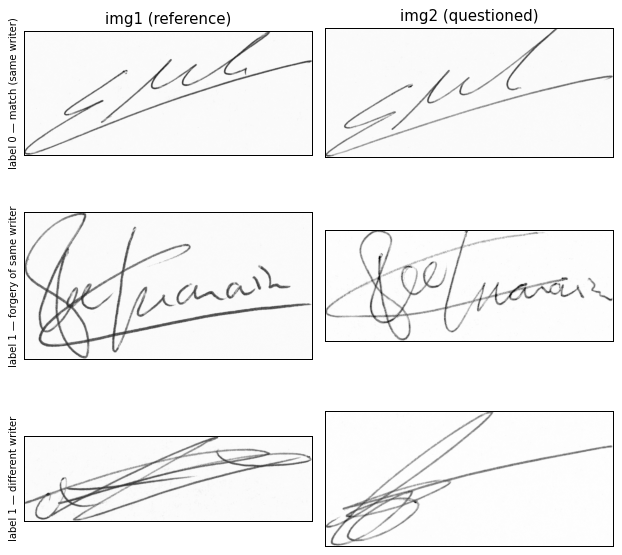

In [ ]:
def show_pair(row, title):
    a = cv2.imread(os.path.join(IMG_DIR, row['img1']), cv2.IMREAD_GRAYSCALE)
    b = cv2.imread(os.path.join(IMG_DIR, row['img2']), cv2.IMREAD_GRAYSCALE)
    fig, ax = plt.subplots(1, 2, figsize=(7, 2.6))
    ax[0].imshow(a, cmap='gray'); ax[0].set_title('img1 (reference)')
    ax[1].imshow(b, cmap='gray'); ax[1].set_title('img2 (questioned)')
    for x in ax:
        x.axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

# one match, one forgery-negative, one different-writer-negative
match_row   = train_pairs[train_pairs.label == 0].iloc[0]
forg_row    = train_pairs[(train_pairs.label == 1) & (train_pairs.img2_is_forg)].iloc[0]
diffw_row   = train_pairs[(train_pairs.label == 1) & (~train_pairs.img2_is_forg)].iloc[0]

show_pair(match_row, 'label 0 — match (same writer)')
show_pair(forg_row,  'label 1 — forgery of the same writer')
show_pair(diffw_row, 'label 1 — different writer')

## 5. Loading the Images

Each signature goes through the tower on its own, so I keep the two sides as two separate
arrays `X1` and `X2` (not stacked like notebook 1). Grayscale, resized to 150×220, scaled
to [0, 1].

In [ ]:
def load_pairs(frame):
    X1, X2, y = [], [], []
    for _, row in frame.iterrows():
        a = cv2.imread(os.path.join(IMG_DIR, row['img1']), cv2.IMREAD_GRAYSCALE)
        b = cv2.imread(os.path.join(IMG_DIR, row['img2']), cv2.IMREAD_GRAYSCALE)
        a = cv2.resize(a, (IMG_W, IMG_H))
        b = cv2.resize(b, (IMG_W, IMG_H))
        # print(a.shape, b.shape)     # checked the resize was landing on (150, 220)
        X1.append(a)
        X2.append(b)
        y.append(row['label'])

    X1 = np.array(X1, dtype='float32')[..., None] / 255.0   # add the channel axis -> (N, H, W, 1)
    X2 = np.array(X2, dtype='float32')[..., None] / 255.0
    return X1, X2, np.array(y)

X1_tr, X2_tr, y_tr = load_pairs(train_pairs)
X1_va, X2_va, y_va = load_pairs(val_pairs)
X1_te, X2_te, y_te = load_pairs(test_pairs)

print('train:', X1_tr.shape, '| val:', X1_va.shape, '| test:', X1_te.shape)
print('train label balance:', dict(zip(*np.unique(y_tr, return_counts=True))))

train: (7000, 150, 220, 1) | val: (1600, 150, 220, 1) | test: (4200, 150, 220, 1)
train label balance: {np.int64(0): np.int64(3500), np.int64(1): np.int64(3500)}


## 6. The Shared Tower

One small CNN that maps a signature to a 128-d embedding: three Conv + BatchNorm + MaxPool
blocks (32 → 64 → 128), then GlobalAveragePooling and a couple of dense layers. I build it
once as `tower` and reuse the same object for both inputs, so the weights are shared
automatically.

In [ ]:
tower = Sequential([
    Input(shape=(IMG_H, IMG_W, 1)),
    Conv2D(32, (3, 3), activation='relu', padding='same'), BatchNormalization(), MaxPooling2D(),
    Conv2D(64, (3, 3), activation='relu', padding='same'), BatchNormalization(), MaxPooling2D(),
    Conv2D(128, (3, 3), activation='relu', padding='same'), BatchNormalization(), MaxPooling2D(),
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128),
], name='tower')

tower.summary()

Model: "tower"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 220, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 220, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 110, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 110, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 110, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 55, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 55, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 55, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 27, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 159,488 (623.00 KB)

 Trainable params: 159,040 (621.25 KB)

 Non-trainable params: 448 (1.75 KB)

## 7. Assembling the Siamese Model

The two inputs each go through the same `tower`, and a Lambda layer computes the Euclidean
distance between the two resulting embeddings. The model's output is that single distance.

In [ ]:
def euclidean_distance(vecs):
    a, b = vecs
    return tf.sqrt(tf.reduce_sum(tf.square(a - b), axis=1, keepdims=True) + 1e-9)

input_a = Input(shape=(IMG_H, IMG_W, 1))
input_b = Input(shape=(IMG_H, IMG_W, 1))

emb_a = tower(input_a)
emb_b = tower(input_b)
distance = Lambda(euclidean_distance)([emb_a, emb_b])

model = Model([input_a, input_b], distance)

## 8. Contrastive Loss and Training

Contrastive loss is

$$L = (1 - Y)\,D^2 + Y\,\max(0,\ m - D)^2$$

where $D$ is the distance and $Y$ the label. For a match ($Y=0$) it's just $D^2$, which
pulls the embeddings together. For a non-match ($Y=1$) it's $\max(0, m-D)^2$, which pushes
them apart until they're at least a margin $m$ away (I use $m = 1$). Pairs already further
than the margin contribute no loss, so the model isn't wasted on already-easy negatives.

In [ ]:
def contrastive_loss(y_true, d):
    margin = 1.0
    y_true = tf.cast(y_true, tf.float32)
    return tf.reduce_mean((1 - y_true) * tf.square(d) +
                          y_true * tf.square(tf.maximum(margin - d, 0)))

model.compile(optimizer=Adam(1e-3), loss=contrastive_loss)

early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

history = model.fit([X1_tr, X2_tr], y_tr,
                    validation_data=([X1_va, X2_va], y_va),
                    epochs=30, batch_size=32,
                    callbacks=[early_stop, reduce_lr])

Epoch 1/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 37s 120ms/step - loss: 0.2709 - val_loss: 0.1612 - learning_rate: 0.0010
Epoch 2/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 17s 80ms/step - loss: 0.1440 - val_loss: 0.0948 - learning_rate: 0.0010
Epoch 3/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 18s 81ms/step - loss: 0.1220 - val_loss: 0.0762 - learning_rate: 0.0010
Epoch 4/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 18s 83ms/step - loss: 0.1090 - val_loss: 0.0577 - learning_rate: 0.0010
Epoch 5/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 19s 85ms/step - loss: 0.1048 - val_loss: 0.0826 - learning_rate: 0.0010
Epoch 6/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 18s 83ms/step - loss: 0.0931 - val_loss: 0.0615 - learning_rate: 0.0010
Epoch 7/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.0897
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
219/219 ━━━━━━━━━━━━━━━━━━━━ 18s 82ms/step - loss: 0.0894 - val_loss: 0.0889 - learning_rate: 0.0010
Epoch 8/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 18s 83ms/step - loss: 0.0800 - val_loss: 0

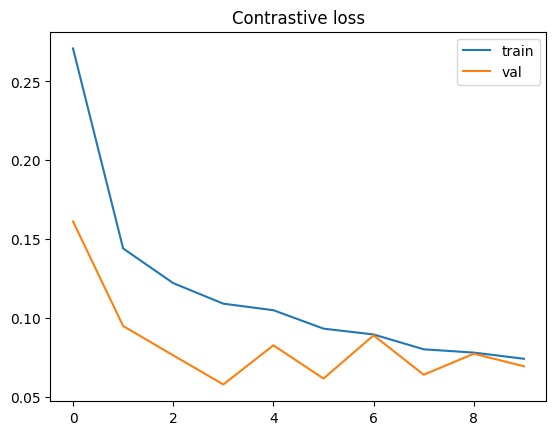

In [ ]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Contrastive loss')
plt.legend()
plt.show()

## 9. Picking a Threshold

The model outputs a distance, not a yes/no, so I need a cutoff. I pick it on the validation
set at the Equal Error Rate — the point where the false-accept rate equals the false-reject
rate. A distance below the cutoff means genuine.

In [ ]:
val_d = model.predict([X1_va, X2_va]).ravel()

# EER: the threshold where false-accept rate ≈ false-reject rate
fpr, tpr, thr = roc_curve(y_va, val_d)
fnr = 1 - tpr
eer_idx = np.nanargmin(np.abs(fpr - fnr))
threshold = thr[eer_idx]

print('threshold:', round(float(threshold), 4))
print('val EER:  ', round(float((fpr[eer_idx] + fnr[eer_idx]) / 2) * 100, 2), '%')

50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step
threshold: 0.4817
val EER:   6.13 %


## 10. Evaluating on Unseen Writers

The real test — writers 049–069, which the model never trained on. I report ROC-AUC
(threshold-free), plus accuracy and the two error rates that actually matter for
verification: FAR (a forgery wrongly accepted) and FRR (a genuine wrongly rejected).

In [ ]:
test_d = model.predict([X1_te, X2_te]).ravel()
pred = (test_d > threshold).astype(int)   # far from reference -> forged

acc = (pred == y_te).mean()
auc = roc_auc_score(y_te, test_d)
far = (test_d[y_te == 1] < threshold).mean()   # forgery accepted as genuine
frr = (test_d[y_te == 0] > threshold).mean()   # genuine rejected as forged

print('Accuracy:', round(acc * 100, 2), '%')
print('ROC-AUC :', round(auc, 3))
print('FAR     :', round(far * 100, 2), '%')
print('FRR     :', round(frr * 100, 2), '%')

132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step
Accuracy: 91.88 %
ROC-AUC : 0.973
FAR     : 9.67 %
FRR     : 6.57 %


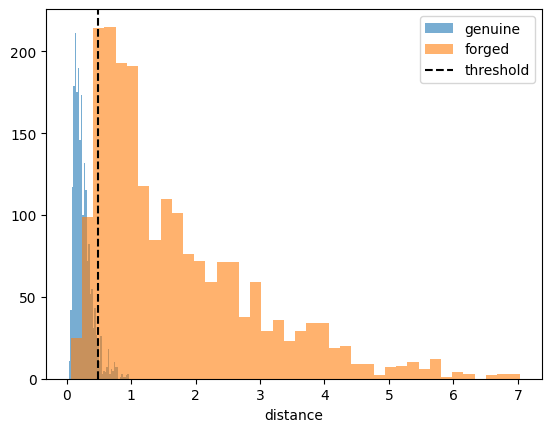

In [ ]:
# how cleanly do the two distance distributions separate?
plt.hist(test_d[y_te == 0], bins=40, alpha=0.6, label='genuine')
plt.hist(test_d[y_te == 1], bins=40, alpha=0.6, label='forged / non-match')
plt.axvline(threshold, color='k', ls='--', label='threshold')
plt.xlabel('distance')
plt.legend()
plt.show()

## 11. Saving the Tower and Threshold

I save the tower on its own (not the full pair-model), because at inference time I want to
embed one signature at a time and compare distances — that's what the app needs.

In [ ]:
tower.save('siamese_embedding.keras')
json.dump({'threshold': float(threshold), 'img_h': IMG_H, 'img_w': IMG_W, 'model': 'siamese_cnn'},
          open('siamese_cnn_meta.json', 'w'))
print('saved tower + meta')

saved tower + meta


## 12. Cross-Dataset Test on NFI

The strongest test of a verification model is a second, independent dataset it never
touched in training or threshold-tuning. I use `sign_data_nfi` (the clean NFI set — a
different source, with *targeted* forgeries; see 01b for why it's a fair test).

I build leak-free pairs from it the same way, embed both sides with the tower I just
trained, and report three numbers:

- **ROC-AUC** — threshold-free, the honest headline for cross-dataset transfer.
- **EER recalibrated on NFI** — the best you could do by re-picking the threshold here.
- **Metrics at the sign_data threshold** — what you actually get transferring the cutoff
  unchanged. Distances usually shift between datasets, so this is worse than the
  recalibrated EER, and that gap is its own lesson about deployment.

In [ ]:
import glob
import re

# locate the clean NFI set (works locally and on Colab after the clone)
NFI_DIR = None
for c in ['sign_data_nfi', '../sign_data_nfi', 'Signature-forgery-verification/sign_data_nfi']:
    if os.path.isdir(c):
        NFI_DIR = c
        break

if NFI_DIR is None:
    print('sign_data_nfi not found — skipping cross-dataset test.')
else:
    # filename is NFI-XXXYYZZZ: signer XXX, owner ZZZ; genuine when signer == owner
    def parse_owner(fn):
        s = re.sub(r'^NFI-', '', os.path.basename(fn))
        s = os.path.splitext(s)[0]
        if re.fullmatch(r'\d{8}', s):
            return s[5:8]          # the owner id
        return None

    nfi_gen  = defaultdict(list)
    nfi_forg = defaultdict(list)
    for f in glob.glob(os.path.join(NFI_DIR, 'genuine', '*')):
        owner = parse_owner(f)
        if owner:
            nfi_gen[owner].append(f)
    for f in glob.glob(os.path.join(NFI_DIR, 'forged', '*')):
        owner = parse_owner(f)
        if owner:
            nfi_forg[owner].append(f)

    nfi_owners = sorted(set(nfi_gen) & set(nfi_forg), key=int)

    def make_nfi_pairs(per_owner=40, seed=7):
        rng = random.Random(seed)
        rows = []
        for o in nfi_owners:
            g = nfi_gen[o]
            if len(g) < 2:
                continue
            for _ in range(per_owner):                 # match
                a, b = rng.sample(g, 2)
                rows.append((a, b, 0))
            for _ in range(per_owner // 2):            # forgery of o
                if nfi_forg.get(o):
                    rows.append((rng.choice(g), rng.choice(nfi_forg[o]), 1))
            for _ in range(per_owner // 2):            # different owner
                other = rng.choice([x for x in nfi_owners if x != o])
                rows.append((rng.choice(g), rng.choice(nfi_gen[other]), 1))
        rng.shuffle(rows)
        return rows

    def load_nfi(rows):
        X1, X2, y = [], [], []
        for a, b, lbl in rows:
            ia = cv2.resize(cv2.imread(a, cv2.IMREAD_GRAYSCALE), (IMG_W, IMG_H))
            ib = cv2.resize(cv2.imread(b, cv2.IMREAD_GRAYSCALE), (IMG_W, IMG_H))
            X1.append(ia)
            X2.append(ib)
            y.append(lbl)
        X1 = np.array(X1, dtype='float32')[..., None] / 255.0
        X2 = np.array(X2, dtype='float32')[..., None] / 255.0
        return X1, X2, np.array(y)

    rows = make_nfi_pairs()
    nX1, nX2, ny = load_nfi(rows)
    print('NFI:', len(nfi_owners), 'owners |', len(rows), 'pairs |',
          'balance', dict(zip(*np.unique(ny, return_counts=True))))

    # embed each side with the trained tower, then Euclidean distance
    e1 = tower.predict(nX1, verbose=0)
    e2 = tower.predict(nX2, verbose=0)
    nd = np.sqrt(((e1 - e2) ** 2).sum(axis=1) + 1e-9)

    nauc = roc_auc_score(ny, nd)
    fpr, tpr, thr = roc_curve(ny, nd)
    fnr = 1 - tpr
    i = np.nanargmin(np.abs(fpr - fnr))
    nfi_eer = (fpr[i] + fnr[i]) / 2

    # transfer the sign_data threshold unchanged
    pred = (nd > threshold).astype(int)
    acc = (pred == ny).mean()
    far = (nd[ny == 1] < threshold).mean()
    frr = (nd[ny == 0] > threshold).mean()

    print()
    print('--- cross-dataset (trained on sign_data, tested on NFI) ---')
    print('ROC-AUC                  :', round(nauc, 3))
    print('EER (recalibrated on NFI):', round(nfi_eer * 100, 2), '%')
    print('at sign_data threshold   -> acc', round(acc * 100, 2), '% | FAR', round(far * 100, 2), '% | FRR', round(frr * 100, 2), '%')

NFI: 30 owners | 2400 pairs | balance {np.int64(0): np.int64(1200), np.int64(1): np.int64(1200)}

--- cross-dataset (trained on sign_data, tested on NFI) ---
ROC-AUC                 : 0.791
EER (recalibrated on NFI): 30.63 %
at sign_data threshold  -> acc 68.71 % | FAR 32.25 % | FRR 30.33 %


## 13. Takeaways

- With leak-free pairs the Siamese network has to learn a real distance metric — it can't
  fall back on the "is the questioned image a forgery?" shortcut that inflated notebook 1.
  On unseen writers it gets **ROC-AUC 0.973**, which is a number I actually trust.
- Genuine and forged pairs land in clearly different parts of the distance distribution
  (the histogram in section 10), and a single EER threshold separates them reasonably well.
- I can enroll a brand new person from one reference signature — no retraining — because
  the tower produces a comparable embedding for any signature.
- Cross-dataset is the honest reality check: AUC holds up at 0.791 on NFI, but transferring
  the threshold unchanged hurts, because the distances shift between datasets. The ranking
  survives; the calibration doesn't. Worth remembering for later.
- **Next:** the tower here is trained from scratch on fairly little data. In notebook 3 I
  try a purpose-built signature tower (and later transfer learning) to push these numbers
  further.